## Topic

Data Leakage; Scaling; scikit-learn Pipelines

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/data-leakage-scaling-scikit-learn-pipelines.html)。

## Question

What is Data Leakage; Scaling; scikit-learn Pipelines, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Data Leakage; Scaling; scikit-learn Pipelines

## Learning Goal

Leakage uses information unavailable at prediction time or allows held-out data to influence training. A pipeline fits preprocessing inside each training fold. It does not repair future-looking features or incorrectly timed labels.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Inspect train-only versus full-data scaler means under a shifted holdout. Add a future target as a feature only in a deliberately invalid copy and explain why the score cannot be trusted.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


train-only mean [-0.11316207 -0.09830566] leaked mean [1.26678519 1.13242199]


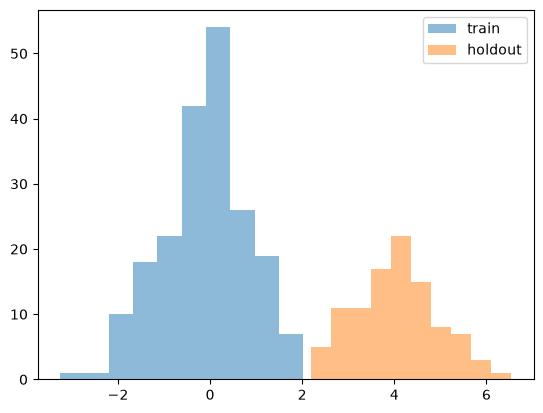

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
rng=np.random.default_rng(7); X=rng.normal(size=(300,2)); X[200:]+=4
y=2*X[:,0]+rng.normal(size=300)
proper=StandardScaler().fit(X[:200]); leaked=StandardScaler().fit(X)
print("train-only mean",proper.mean_,"leaked mean",leaked.mean_)
model=make_pipeline(StandardScaler(),Ridge()).fit(X[:200],y[:200])
assert np.allclose(model[0].mean_,X[:200].mean(axis=0))
plt.hist(X[:200,0],alpha=.5,label="train");plt.hist(X[200:,0],alpha=.5,label="holdout");plt.legend();plt.show()

## Expected Observations

The full-data scaler knows the holdout distribution. Leakage need not improve every score to invalidate the evaluation procedure.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. Leakage uses information unavailable at prediction time or allows held-out data to influence training. A pipeline fits preprocessing inside each training fold. It does not repair future-looking features or incorrectly timed labels.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. The full-data scaler knows the holdout distribution. Leakage need not improve every score to invalidate the evaluation procedure.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/data-leakage-scaling-scikit-learn-pipelines.html)
